<a href="https://colab.research.google.com/github/Visualizacao-Dados-BI-T3/mod1-projeto-avaliativo/blob/feature%2Fnotebook/notebook/projeto_avaliativo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Opção 1: Acessar dados do FreeSQL através da string de conexão

## Pré requisitos:
* fazer conta,
* verificar email e
* criar segundo fator de autenticação.

## Depois de logado:
* Clicar no botão `Connect with Python (Node, Go..)`
* Copiar código sugerido para a linguagem Python
* Pedir adaptação para a IA da sua preferência para colocar no padrão de .ipynb
* Configurar secrets no Colab

In [ ]:
# 1. Instalar a biblioteca oracledb
!pip install oracledb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.0 MB/s eta 0:00:00


In [ ]:
import oracledb
from google.colab import userdata

# 2. Recuperar a senha salva de forma segura nos Secrets do Colab
db_password = userdata.get('DB_PASSWORD')

local_dsn = "tcps://db.freesql.com:2484/26ai_un3c1"

try:
    # 3. Conectar ao banco de dados Oracle
    connection = oracledb.connect(
        user="CIBELLE_COSTA_SCHEMA_U9FPQ",
        password=db_password,
        dsn=local_dsn
    )

    print("Conectado ao Oracle Database com sucesso!")

    # # 4. Executar consulta de teste
    # cursor = connection.cursor()
    # cursor.execute("SELECT * FROM HR.EMPLOYEES")
    # # for result in cursor:
    # #     print("Resultado da consulta:", result)

    # # 5. Fechar conexões
    # cursor.close()
    # connection.close()

except Exception as e:
    print("Erro ao conectar ao banco de dados:", e)




Conectado ao Oracle Database com sucesso!


In [ ]:
import pandas as pd

In [ ]:
df_conection = pd.read_sql("SELECT * FROM HR.EMPLOYEES",connection )

df_conection

/tmp/ipykernel_3911/2815927652.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_conection = pd.read_sql("SELECT * FROM HR.EMPLOYEES",connection )


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,PHONE_NUMBER,HIRE_DATE,JOB_ID,SALARY,COMMISSION_PCT,MANAGER_ID,DEPARTMENT_ID
0,100,Steven,King,SKING,1.515.555.0100,2013-06-17,AD_PRES,24000.0,NaN,NaN,90.0
1,101,Neena,Yang,NYANG,1.515.555.0101,2015-09-21,AD_VP,17000.0,NaN,100.0,90.0
2,102,Lex,Garcia,LGARCIA,1.515.555.0102,2011-01-13,AD_VP,17000.0,NaN,100.0,90.0
3,103,Alexander,James,AJAMES,1.590.555.0103,2016-01-03,IT_PROG,9000.0,NaN,102.0,60.0
4,104,Bruce,Miller,BMILLER,1.590.555.0104,2017-05-21,IT_PROG,6000.0,NaN,103.0,60.0
...,...,...,...,...,...,...,...,...,...,...,...
102,202,Pat,Davis,PDAVIS,1.603.555.0167,2015-08-17,MK_REP,6000.0,NaN,201.0,20.0
103,203,Susan,Jacobs,SJACOBS,1.515.555.0168,2012-06-07,HR_REP,6500.0,NaN,101.0,40.0
104,204,Hermann,Brown,HBROWN,1.515.555.0169,2012-06-07,PR_REP,10000.0,NaN,101.0,70.0
105,205,Shelley,Higgins,SHIGGINS,1.515.555.0170,2012-06-07,AC_MGR,12008.0,NaN,101.0,110.0


# Opção 2: Fazer upload do arquivo no Colab

## Pontos negativos:
* A cada novo acesso o arquivo "some" e novo upload deve ser feito,
* Reduz a reprodutibilidade do código. Um terceiro que acessar apenas o notebook (.ipynb) não terá acesso ao seu arquivo

In [ ]:
df = pd.read_csv("query_1.csv")

df

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE
0,200,Jennifer,Whalen,4400,Administration,Administration Assistant
1,201,Michael,Martinez,13000,Marketing,Marketing Manager
2,202,Pat,Davis,6000,Marketing,Marketing Representative
3,114,Den,Li,11000,Purchasing,Purchasing Manager
4,115,Alexander,Khoo,3100,Purchasing,Purchasing Clerk
...,...,...,...,...,...,...
102,112,Jose Manuel,Urman,7800,Finance,Accountant
103,113,Luis,Popp,6900,Finance,Accountant
104,205,Shelley,Higgins,12008,Accounting,Accounting Manager
105,206,William,Gietz,8300,Accounting,Public Accountant


# Opção 3: Usando o link Raw do arquivo .csv no GitHub

Também é possível carregar o CSV diretamente do GitHub, sem precisar baixar o arquivo para o computador ou fazer upload no Colab. Para mais informações, ver o início da aula do dia 25/09/2026

## Para isso:
1. Acesse o repositório no GitHub.
2. Abra a pasta onde está o arquivo .csv.
3. Clique no arquivo que deseja utilizar.
4. Na página do arquivo, clique no botão Raw.
5. Copie o endereço (URL) da página que abriu.
6. Cole esse endereço dentro do pd.read_csv().

### Exemplo:

In [ ]:
url_query_1 = "LINK_RAW_DO_QUERY_01.csv"
df_salarios = pd.read_csv(url_query_1)

url_query_2 = "LINK_RAW_DO_QUERY_02.csv"
df_regioes = pd.read_csv(url_query_2)

# EDA da `query_1.csv`

## 1. Importação da base resultante da query *1*
Obs.: Left join departamentod e jobs where salary > 0

In [27]:
import pandas as pd

df1 = pd.read_csv("https://raw.githubusercontent.com/Visualizacao-Dados-BI-T3/mod1-projeto-avaliativo/refs/heads/main/data/query_1.csv")

df1.head() # visualizando as primeiras 5 linhas

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,JOB_TITLE
0,200,Jennifer,Whalen,4400,Administration,Administration Assistant
1,201,Michael,Martinez,13000,Marketing,Marketing Manager
2,202,Pat,Davis,6000,Marketing,Marketing Representative
3,114,Den,Li,11000,Purchasing,Purchasing Manager
4,115,Alexander,Khoo,3100,Purchasing,Purchasing Clerk


In [28]:
df1.shape

(107, 6)

In [29]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   EMPLOYEE_ID      107 non-null    int64 
 1   FIRST_NAME       107 non-null    object
 2   LAST_NAME        107 non-null    object
 3   SALARY           107 non-null    int64 
 4   DEPARTMENT_NAME  106 non-null    object
 5   JOB_TITLE        107 non-null    object
dtypes: int64(2), object(4)
memory usage: 5.1+ KB


In [30]:
df1.dtypes

,0
EMPLOYEE_ID,int64
FIRST_NAME,object
LAST_NAME,object
SALARY,int64
DEPARTMENT_NAME,object
JOB_TITLE,object


In [31]:
df1.columns

Index(['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME',
       'JOB_TITLE'],
      dtype='object')

## 2. Renomeando as colunas

obs.: consulta a IA e a Tassiana

In [32]:
df1 = df1.rename(columns={
    "EMPLOYEE_ID": "cod_funcionario",
    "FIRST_NAME": "primeiro_nome",
    "LAST_NAME": "ultimo_nome",
    "SALARY": "salario",
    "DEPARTMENT_NAME": 'nome_depto',
    "JOB_TITLE": 'cargo'
})

df1.columns

Index(['cod_funcionario', 'primeiro_nome', 'ultimo_nome', 'salario',
       'nome_depto', 'cargo'],
      dtype='object')

## 3. Olhando as estatísticias (numéricas separadas de categóricas)

In [33]:
df1.describe()

,cod_funcionario,salario
count,107.000000,107.000000
mean,153.000000,6461.831776
std,31.032241,3909.579731
min,100.000000,2100.000000
25%,126.500000,3100.000000
50%,153.000000,6200.000000
75%,179.500000,8900.000000
max,206.000000,24000.000000


In [34]:
df1.describe(include="object")

,primeiro_nome,ultimo_nome,nome_depto,cargo
count,107,107,106,107
unique,92,102,11,19
top,John,Taylor,Shipping,Sales Representative
freq,3,2,45,30


## 4. Verificando a presença de valores nulos

In [35]:
# Dups?
# Nulos
# Tipos corretos
# Os valores fazem sentido?

In [37]:
df1.isnull().sum()

,0
cod_funcionario,0
primeiro_nome,0
ultimo_nome,0
salario,0
nome_depto,1
cargo,0


In [38]:
df1.isna().sum()

,0
cod_funcionario,0
primeiro_nome,0
ultimo_nome,0
salario,0
nome_depto,1
cargo,0


In [39]:
df1.isna().mean() * 100

,0
cod_funcionario,0.000000
primeiro_nome,0.000000
ultimo_nome,0.000000
salario,0.000000
nome_depto,0.934579
cargo,0.000000


## 5. Removendo valores nulos (encontrado um nulo na coluna de nome depto)

In [40]:
df1.shape

(107, 6)

In [41]:
df1 = df1.dropna(subset=["salario"])

In [74]:
df1.shape

(107, 6)

In [75]:
df1 = df1.dropna(subset=["nome_depto"])

In [76]:
df1.shape

(106, 6)

## (Opcional) Caso eu quisesse preencher nulos

In [77]:
df1.shape

(106, 6)

In [78]:
df1["nome_depto"]

,nome_depto
0,Administration
1,Marketing
2,Marketing
3,Purchasing
4,Purchasing
...,...
101,Finance
102,Finance
103,Finance
104,Accounting


In [79]:
df1[
    df1["nome_depto"].isna()
]

,cod_funcionario,primeiro_nome,ultimo_nome,salario,nome_depto,cargo


In [80]:
df1["nome_depto"] = df1["nome_depto"].fillna("Sem Departamento")

In [81]:
df1[
    df1["nome_depto"] == "Sem Departamento"
]

,cod_funcionario,primeiro_nome,ultimo_nome,salario,nome_depto,cargo


## 6. Verificando a presença de valores duplicados

In [82]:
df1.duplicated().sum()

np.int64(0)

In [83]:
df1[df1.duplicated(subset=["primeiro_nome", "ultimo_nome"])]

,cod_funcionario,primeiro_nome,ultimo_nome,salario,nome_depto,cargo


In [84]:
df1[df1.duplicated(subset="primeiro_nome")]

,cod_funcionario,primeiro_nome,ultimo_nome,salario,nome_depto,cargo
21,131,James,Marlow,2500,Shipping,Stock Clerk
24,134,Michael,Rogers,2900,Shipping,Stock Clerk
41,186,Julia,Dellinger,3400,Shipping,Shipping Clerk
44,189,Jennifer,Dilly,3600,Shipping,Shipping Clerk
46,191,Randall,Perkins,2500,Shipping,Shipping Clerk
52,197,Kevin,Feeney,3000,Shipping,Shipping Clerk
55,103,Alexander,James,9000,IT,Programmer
61,145,John,Singh,14000,Sales,Sales Manager
62,146,Karen,Partners,13500,Sales,Sales Manager
67,151,David,Bernstein,9500,Sales,Sales Representative


In [85]:
df1.duplicated(subset="primeiro_nome").sum()

np.int64(15)

In [86]:
# df1['salario'] = pd.to_numeric(df1['salario'])
# df1['data'] = pd.to_datetime(df1['data'], errors=)

 # EDA da `query_2.csv`
 Obs.: `WHERE regiao.REGION_NAME IS NOT NULL`

In [87]:
df2 = pd.read_csv("https://raw.githubusercontent.com/Visualizacao-Dados-BI-T3/mod1-projeto-avaliativo/refs/heads/main/data/query_2.csv")

df2.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_NAME,STREET_ADDRESS,CITY,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
0,100,Steven,King,24000,Executive,2004 Charade Rd,Seattle,Washington,United States of America,Americas
1,101,Neena,Yang,17000,Executive,2004 Charade Rd,Seattle,Washington,United States of America,Americas
2,102,Lex,Garcia,17000,Executive,2004 Charade Rd,Seattle,Washington,United States of America,Americas
3,103,Alexander,James,9000,IT,2014 Jabberwocky Rd,Southlake,Texas,United States of America,Americas
4,104,Bruce,Miller,6000,IT,2014 Jabberwocky Rd,Southlake,Texas,United States of America,Americas


In [88]:
def diagnostico(tabela):
  "SELECT, INSERT, UPDATE, CREATE -> SQL"
  "PostgreSQL -> banco"
  "def, print, dataframe -> Python"

  print('df.shape:', tabela.shape)

  colunas = tabela.columns.to_list()
  print('df.columns:', colunas)

  # Selecionar colunas numéricas
  numericas = tabela.select_dtypes(include='number')

  # Selecionar colunas categóricas
  categoricas = tabela.select_dtypes(
  include=['object', 'category']
  )

  print('Duplicatas:', tabela.duplicated().sum())

  print(f"\nValores nulos")
  display(tabela.isna().sum())

  print(f"\ndf.describe()")
  display(tabela.describe())

  # verificar
  print("\nModa:")
  for coluna in numericas.columns:
    display(f"{coluna}: {tabela[coluna].mode()[0]}")

  print(f"\nResumo das colunas: tipo, ausentes, percentual ausentes e valores únicos")
  resumo = pd.DataFrame({
'tipo': tabela.dtypes,
'ausentes': tabela.isna().sum(),
'percentual_ausentes': tabela.isna().mean() * 100,
'valores_unicos': tabela.nunique()
})

  for coluna in categoricas.columns:
    print(f"\n{coluna}")
    display(tabela[coluna].value_counts(dropna=False))

  display(resumo)

In [89]:
diagnostico(df2)

df.shape: (106, 10)
df.columns: ['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME', 'STREET_ADDRESS', 'CITY', 'STATE_PROVINCE', 'COUNTRY_NAME', 'REGION_NAME']
Duplicatas: 0

Valores nulos


,0
EMPLOYEE_ID,0
FIRST_NAME,0
LAST_NAME,0
SALARY,0
DEPARTMENT_NAME,0
STREET_ADDRESS,0
CITY,0
STATE_PROVINCE,1
COUNTRY_NAME,0
REGION_NAME,0



df.describe()


,EMPLOYEE_ID,SALARY
count,106.000000,106.000000
mean,152.764151,6456.754717
std,31.083161,3927.798234
min,100.000000,2100.000000
25%,126.250000,3100.000000
50%,152.500000,6150.000000
75%,179.750000,8950.000000
max,206.000000,24000.000000



Moda:


...


COUNTRY_NAME


,count
COUNTRY_NAME,
United States of America,68
United Kingdom of Great Britain and Northern Ireland,35
Canada,2
Germany,1



REGION_NAME


,count
REGION_NAME,
Americas,70
Europe,36


,tipo,ausentes,percentual_ausentes,valores_unicos
EMPLOYEE_ID,int64,0,0.000000,106
FIRST_NAME,object,0,0.000000,91
LAST_NAME,object,0,0.000000,102
SALARY,int64,0,0.000000,58
DEPARTMENT_NAME,object,0,0.000000,11
STREET_ADDRESS,object,0,0.000000,7
CITY,object,0,0.000000,7
STATE_PROVINCE,object,1,0.943396,6
COUNTRY_NAME,object,0,0.000000,4
REGION_NAME,object,0,0.000000,2


In [90]:
df_funcao = diagnostico(df1)

df.shape: (106, 6)
df.columns: ['cod_funcionario', 'primeiro_nome', 'ultimo_nome', 'salario', 'nome_depto', 'cargo']
Duplicatas: 0

Valores nulos


,0
cod_funcionario,0
primeiro_nome,0
ultimo_nome,0
salario,0
nome_depto,0
cargo,0



df.describe()


,cod_funcionario,salario
count,106.000000,106.000000
mean,152.764151,6456.754717
std,31.083161,3927.798234
min,100.000000,2100.000000
25%,126.250000,3100.000000
50%,152.500000,6150.000000
75%,179.750000,8950.000000
max,206.000000,24000.000000



Moda:


...


nome_depto


,count
nome_depto,
Shipping,45
Sales,34
Purchasing,6
Finance,6
IT,5
Executive,3
Marketing,2
Accounting,2
Administration,1



cargo


,count
cargo,
Sales Representative,29
Shipping Clerk,20
Stock Clerk,20
Programmer,5
Accountant,5
Sales Manager,5
Purchasing Clerk,5
Stock Manager,5
Administration Vice President,2


,tipo,ausentes,percentual_ausentes,valores_unicos
cod_funcionario,int64,0,0.0,106
primeiro_nome,object,0,0.0,91
ultimo_nome,object,0,0.0,102
salario,int64,0,0.0,58
nome_depto,object,0,0.0,11
cargo,object,0,0.0,19


# TO DO

## Quem não executou GROUP BY no SQL deve fazer no notebook para responder às perguntas do vídeo/insights do README

### Exemplo de agregação:

In [91]:
# group by

df1.groupby("cargo")["salario"].sum()

,salario
cargo,
Accountant,39600
Accounting Manager,12008
Administration Assistant,4400
Administration Vice President,34000
Finance Manager,12008
Human Resources Representative,6500
Marketing Manager,13000
Marketing Representative,6000
President,24000


In [92]:

df1.groupby("nome_depto")["salario"].sum()

,salario
nome_depto,
Accounting,20308
Administration,4400
Executive,58000
Finance,51608
Human Resources,6500
IT,28800
Marketing,19000
Public Relations,10000
Purchasing,24900


In [93]:
df1.columns

Index(['cod_funcionario', 'primeiro_nome', 'ultimo_nome', 'salario',
       'nome_depto', 'cargo'],
      dtype='object')

In [94]:
df1.groupby(["nome_depto", "cargo"]).agg(
    media_salarial = ("salario", "mean"),
  mediana_slarial = ("salario", "median")
).reset_index()

,nome_depto,cargo,media_salarial,mediana_slarial
0,Accounting,Accounting Manager,12008.000000,12008.0
1,Accounting,Public Accountant,8300.000000,8300.0
2,Administration,Administration Assistant,4400.000000,4400.0
3,Executive,Administration Vice President,17000.000000,17000.0
4,Executive,President,24000.000000,24000.0
5,Finance,Accountant,7920.000000,7800.0
6,Finance,Finance Manager,12008.000000,12008.0
7,Human Resources,Human Resources Representative,6500.000000,6500.0
8,IT,Programmer,5760.000000,4800.0
9,Marketing,Marketing Manager,13000.000000,13000.0


In [95]:
df2.columns

Index(['EMPLOYEE_ID', 'FIRST_NAME', 'LAST_NAME', 'SALARY', 'DEPARTMENT_NAME',
       'STREET_ADDRESS', 'CITY', 'STATE_PROVINCE', 'COUNTRY_NAME',
       'REGION_NAME'],
      dtype='object')

In [96]:
df2.groupby(["REGION_NAME", "COUNTRY_NAME", "STATE_PROVINCE", "CITY"]).agg(
    media_salarial = ("SALARY", "mean"),
  mediana_slarial = ("SALARY", "median")
).reset_index()

,REGION_NAME,COUNTRY_NAME,STATE_PROVINCE,CITY,media_salarial,mediana_slarial
0,Americas,Canada,Ontario,Toronto,9500.000000,9500.0
1,Americas,United States of America,California,South San Francisco,3475.555556,3100.0
2,Americas,United States of America,Texas,Southlake,5760.000000,4800.0
3,Americas,United States of America,Washington,Seattle,8845.333333,8000.0
4,Europe,Germany,Bavaria,Munich,10000.000000,10000.0
5,Europe,United Kingdom of Great Britain and Northern I...,Oxford,Oxford,8955.882353,8900.0


In [97]:
df2.groupby("REGION_NAME").agg(
    media_salarial = ("SALARY", "mean"),
  mediana_slarial = ("SALARY", "median")
).reset_index()

,REGION_NAME,media_salarial,mediana_slarial
0,Americas,5191.657143,3300.0
1,Europe,8916.666667,8900.0


In [98]:
df2.groupby("COUNTRY_NAME").agg(
    media_salarial = ("SALARY", "mean"),
  mediana_slarial = ("SALARY", "median")
).reset_index()

,COUNTRY_NAME,media_salarial,mediana_slarial
0,Canada,9500.000000,9500.0
1,Germany,10000.000000,10000.0
2,United Kingdom of Great Britain and Northern I...,8885.714286,8800.0
3,United States of America,5064.941176,3250.0


In [99]:
df2.groupby("STATE_PROVINCE").agg(
    media_salarial = ("SALARY", "mean"),
  mediana_slarial = ("SALARY", "median")
).reset_index()

,STATE_PROVINCE,media_salarial,mediana_slarial
0,Bavaria,10000.000000,10000.0
1,California,3475.555556,3100.0
2,Ontario,9500.000000,9500.0
3,Oxford,8955.882353,8900.0
4,Texas,5760.000000,4800.0
5,Washington,8845.333333,8000.0


In [100]:
df2.groupby("CITY").agg(
    media_salarial = ("SALARY", "mean"),
  mediana_slarial = ("SALARY", "median")
).reset_index()

,CITY,media_salarial,mediana_slarial
0,London,6500.000000,6500.0
1,Munich,10000.000000,10000.0
2,Oxford,8955.882353,8900.0
3,Seattle,8845.333333,8000.0
4,South San Francisco,3475.555556,3100.0
5,Southlake,5760.000000,4800.0
6,Toronto,9500.000000,9500.0


# Criação dos gráficos

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df1.columns

Index(['cod_funcionario', 'primeiro_nome', 'ultimo_nome', 'salario',
       'nome_depto', 'cargo'],
      dtype='object')

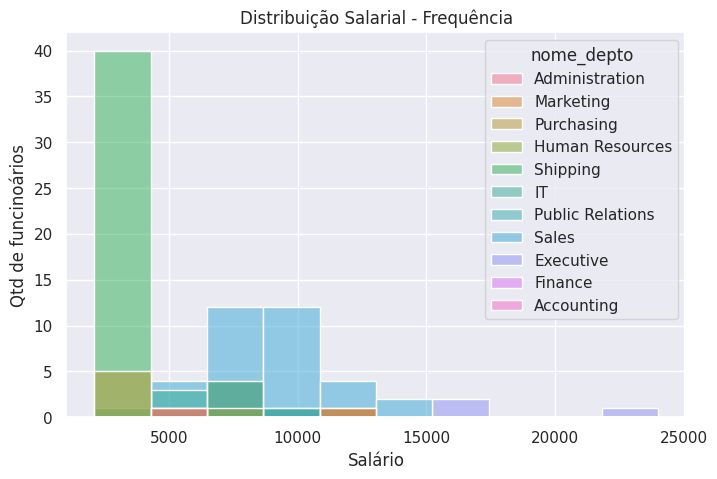

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(
    df1,
    x="salario",
    hue="nome_depto",
    bins=10
  )

plt.title("Distribuição Salarial - Frequência")
plt.xlabel("Salário")
plt.ylabel("Qtd de funcinoários")

plt.savefig("distribuicao_salario_cargo.png")

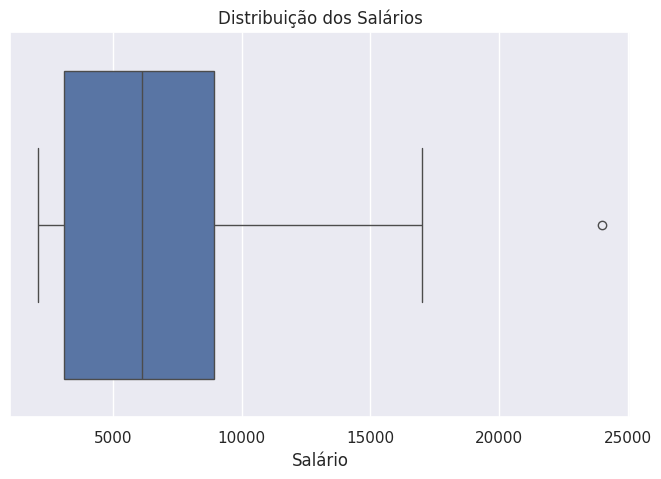

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(
    df1,
    x="salario",
  )

plt.title("Distribuição dos Salários")

plt.xlabel("Salário")

plt.savefig("distribuicao_salarial.png")

In [105]:
salario_depto = (df1.groupby("nome_depto").agg(
    qtd_funcionarios=("cod_funcionario", "nunique"),
    salario_medio=("salario", "mean"),
    salario_mediana=("salario", "median"))).reset_index().sort_values("salario_medio", ascending=False)

salario_depto

,nome_depto,qtd_funcionarios,salario_medio,salario_mediana
2,Executive,3,19333.333333,17000.0
0,Accounting,2,10154.000000,10154.0
7,Public Relations,1,10000.000000,10000.0
6,Marketing,2,9500.000000,9500.0
9,Sales,34,8955.882353,8900.0
3,Finance,6,8601.333333,8000.0
4,Human Resources,1,6500.000000,6500.0
5,IT,5,5760.000000,4800.0
1,Administration,1,4400.000000,4400.0
8,Purchasing,6,4150.000000,2850.0


<Figure size 900x900 with 0 Axes>

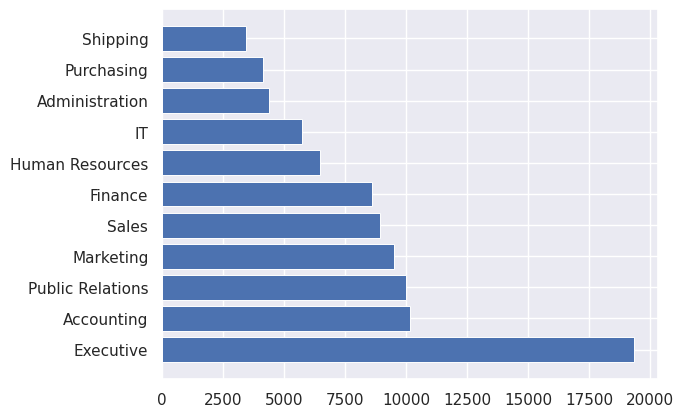

In [106]:
plt.figure(figsize=(9,9))

fig, ax = plt.subplots()

ax.barh(salario_depto['nome_depto'],salario_depto["salario_medio"], edgecolor="white", linewidth=0.7)

plt.show()

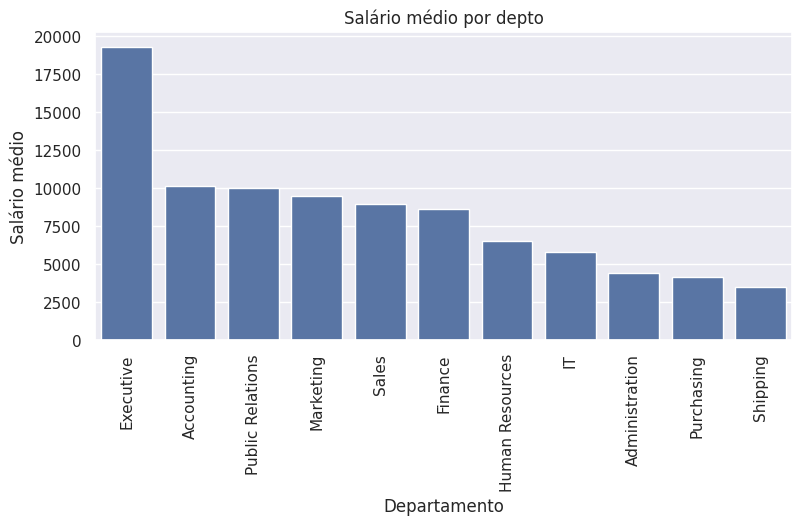

In [114]:
plt.figure(figsize=(9,4))

sns.barplot(salario_depto, x="nome_depto", y="salario_medio")


plt.title("Salário médio por depto")

plt.xlabel("Departamento")
plt.ylabel("Salário médio")

plt.xticks(rotation=90)

plt.savefig("salario_medio_depto.png")
plt.show()

In [108]:
funcionarios_regiao = (df2.groupby("REGION_NAME")["EMPLOYEE_ID"].count()).reset_index()

funcionarios_regiao

,REGION_NAME,EMPLOYEE_ID
0,Americas,70
1,Europe,36


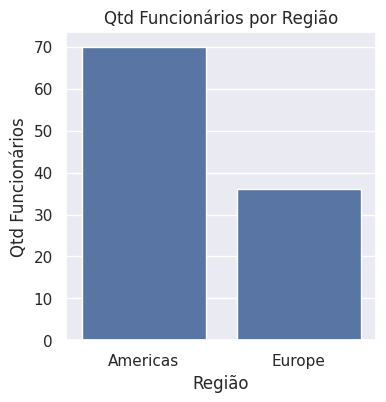

In [112]:
plt.figure(figsize=(4,4))

sns.barplot(funcionarios_regiao, x="REGION_NAME", y="EMPLOYEE_ID")


plt.title("Qtd Funcionários por Região")

plt.xlabel("Região")
plt.ylabel("Qtd Funcionários")

plt.savefig("qtd_funcionarios_regiao.png")
plt.show()

In [110]:
salario_state = (df2.groupby("STATE_PROVINCE").agg(
    salario_medio=("SALARY", "mean"),
    salario_mediana=("SALARY", "median"))).reset_index().sort_values("salario_medio", ascending=False)

salario_state

,STATE_PROVINCE,salario_medio,salario_mediana
0,Bavaria,10000.000000,10000.0
2,Ontario,9500.000000,9500.0
3,Oxford,8955.882353,8900.0
5,Washington,8845.333333,8000.0
4,Texas,5760.000000,4800.0
1,California,3475.555556,3100.0


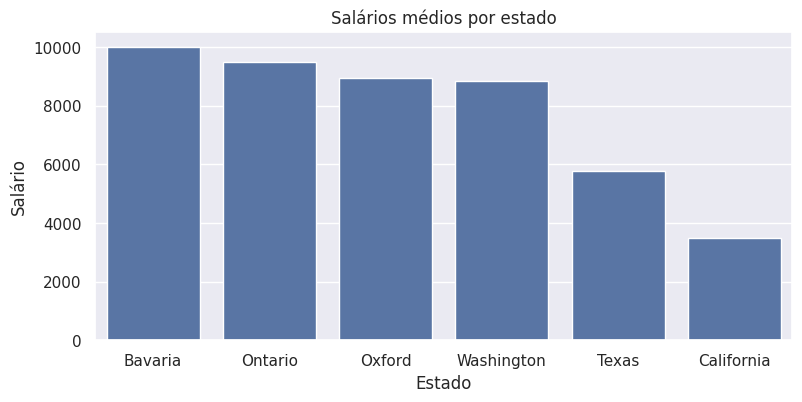

In [113]:
plt.figure(figsize=(9,4))

sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

sns.barplot(salario_state, x="STATE_PROVINCE", y="salario_medio")

plt.title("Salários médios por estado")

plt.xlabel("Estado")
plt.ylabel("Salário")

plt.savefig("salario_medio_estado.png")
plt.show()